# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# Load your uploaded file (path "/content/listings.csv.gz")
filepath = '/content/listings.csv.gz'
df = pd.read_csv(filepath, compression='gzip')

# Display the first few rows
display(df.head())

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27262,https://www.airbnb.com/rooms/27262,20250926033717,2025-09-27,previous scrape,"AQA-No7, Great mattress, high speed internet",THE MATTRESS - KING KOIL - Camden Luxury 160x2...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,37177,...,4.97,4.75,4.71,00002433111,t,1,1,0,0,0.18
1,33945,https://www.airbnb.com/rooms/33945,20250926033717,2025-09-26,city scrape,Spacious Cosy aprtm very close to Metro!,Apartment located near metro station. Safe nei...,Neighbourhood is alive all day and safe all da...,https://a0.muscache.com/pictures/1a7a1026-f5f1...,146553,...,4.91,4.64,4.81,00000874421,f,1,1,0,0,0.49
2,49489,https://www.airbnb.com/rooms/49489,20250926033717,2025-09-26,city scrape,Ermou 44 - 3bdr apt in the heart of Athens,"Fully furnished, 98 sq.mt., apartment on 44 Er...",The apartment is located at the commercial cen...,https://a0.muscache.com/pictures/9640239/4bfd2...,225612,...,4.87,4.89,4.69,00000876484,t,3,3,0,0,0.83
3,60394,https://www.airbnb.com/rooms/60394,20250926033717,2025-09-26,city scrape,Cosy apartment! Great central Athens location!,Fully furnished cozy apartment in the best nei...,Very centrally located with a feeling of a qui...,https://a0.muscache.com/pictures/477282/db550f...,290864,...,4.97,4.92,4.92,00000508830,f,1,1,0,0,0.29
4,134340,https://www.airbnb.com/rooms/134340,20250926033717,2025-09-27,previous scrape,Neo Pagrati Athens Apartment,Little gem with the best of all worlds! Locate...,Our street is a small one with very little tra...,https://a0.muscache.com/pictures/1232312/4edeb...,659406,...,4.93,4.56,4.83,00002821300,f,1,1,0,0,0.36


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Missing values per column (Top 20):
neighbourhood_group_cleansed    15584
host_neighbourhood               9836
neighborhood_overview            8075
neighbourhood                    8075
host_about                       7695
host_location                    5178
review_scores_communication      2343
review_scores_location           2343
review_scores_value              2343
last_review                      2343
first_review                     2343
review_scores_checkin            2343
review_scores_accuracy           2343
review_scores_cleanliness        2343
host_response_time               1772
host_response_rate               1772
beds                             1081
price                            1060
estimated_revenue_l365d          1060
bathrooms                        1057
dtype: int64


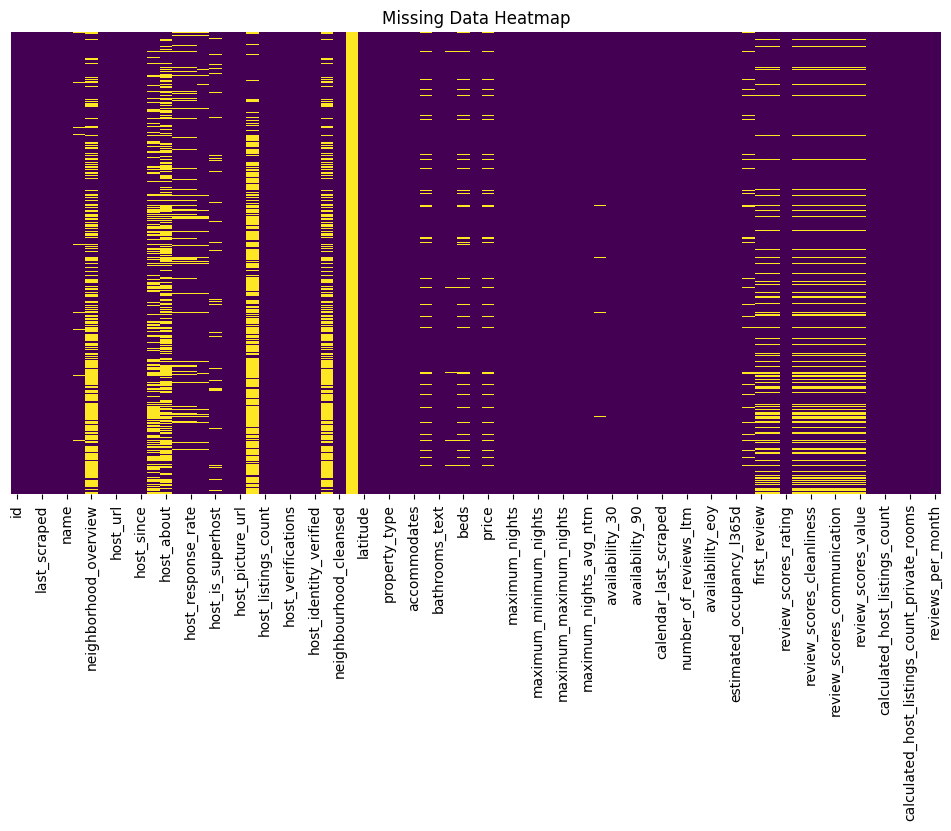

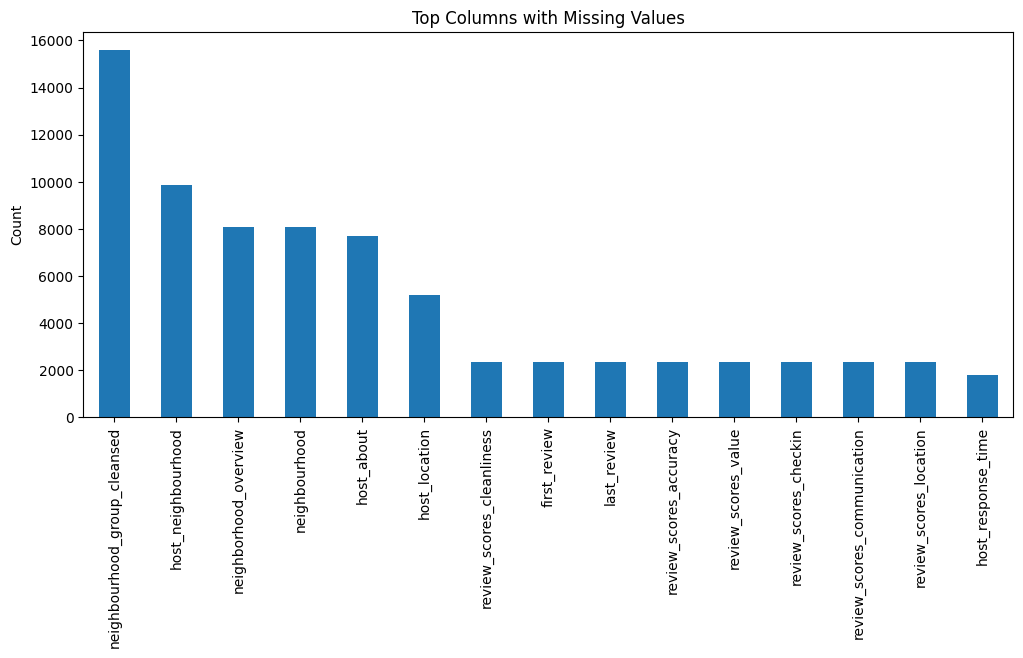

In [9]:
# 1. Count null values for each column
missing_counts = df.isnull().sum()
print("Missing values per column (Top 20):")
print(missing_counts.sort_values(ascending=False).head(20))

# 2. Visualize missing values with a heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

# 3. Bar chart for top missing columns
missing_counts[missing_counts > 0].sort_values(ascending=False).head(15).plot(kind='bar', figsize=(12,5))
plt.title('Top Columns with Missing Values')
plt.ylabel('Count')
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response: 🔧
1.Neighbourhood_group_cleansed, host_neighbourhood, neighborhood_overview

2.Neighbourhood_group_cleased as it has the most missing values.

3.All of the above mentioned including neighborhood and host_about.


## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [3]:
# Identify columns to drop based on high missing values or redundancy
cols_to_drop = ['neighborhood_group_cleansed', 'license', 'calendar_updated', 'listing_url', 'picture_url']

# Filter list to only include columns that actually exist in the dataframe
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

# Drop the columns
df.drop(columns=cols_to_drop, inplace=True)

print(f"Dropped columns: {cols_to_drop}")
print(f"New shape: {df.shape}")
display(df.head())

Dropped columns: ['license', 'calendar_updated', 'listing_url', 'picture_url']
New shape: (15584, 75)


,id,scrape_id,last_scraped,source,name,description,neighborhood_overview,host_id,host_url,host_name,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,27262,20250926033717,2025-09-27,previous scrape,"AQA-No7, Great mattress, high speed internet",THE MATTRESS - KING KOIL - Camden Luxury 160x2...,NaN,37177,https://www.airbnb.com/users/show/37177,Emmanouil,...,4.86,4.97,4.75,4.71,t,1,1,0,0,0.18
1,33945,20250926033717,2025-09-26,city scrape,Spacious Cosy aprtm very close to Metro!,Apartment located near metro station. Safe nei...,Neighbourhood is alive all day and safe all da...,146553,https://www.airbnb.com/users/show/146553,Katerina,...,4.89,4.91,4.64,4.81,f,1,1,0,0,0.49
2,49489,20250926033717,2025-09-26,city scrape,Ermou 44 - 3bdr apt in the heart of Athens,"Fully furnished, 98 sq.mt., apartment on 44 Er...",The apartment is located at the commercial cen...,225612,https://www.airbnb.com/users/show/225612,Stathis,...,4.84,4.87,4.89,4.69,t,3,3,0,0,0.83
3,60394,20250926033717,2025-09-26,city scrape,Cosy apartment! Great central Athens location!,Fully furnished cozy apartment in the best nei...,Very centrally located with a feeling of a qui...,290864,https://www.airbnb.com/users/show/290864,Dimitra,...,4.92,4.97,4.92,4.92,f,1,1,0,0,0.29
4,134340,20250926033717,2025-09-27,previous scrape,Neo Pagrati Athens Apartment,Little gem with the best of all worlds! Locate...,Our street is a small one with very little tra...,659406,https://www.airbnb.com/users/show/659406,Konstantinos,...,4.97,4.93,4.56,4.83,f,1,1,0,0,0.36


### Reflection:
1. Which columns did you drop?
   
2. Why were they not useful from a business perspective?
  
3. What could go wrong if you left them in?
  

### ✍️ Your Response:
1. License, calendar_updated, and URL fields.
2. They were mostly empty or unhelpful for the anylasis.
3. Messy data, irrelevent collums and potentially skewed results.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [8]:
# 1. Fill missing 'reviews_per_month' with 0
# If it's NaN, it usually means the property has zero reviews.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# 2. Fill missing 'review_scores_rating' with the median
# Using the median avoids the influence of extreme outliers.
rating_median = df['review_scores_rating'].median()
df['review_scores_rating'] = df['review_scores_rating'].fillna(rating_median)

print(f"Imputed reviews_per_month with 0.")
print(f"Imputed review_scores_rating with median value: {rating_median}")

# Verify counts
print(df[['reviews_per_month', 'review_scores_rating']].isnull().sum())

Imputed reviews_per_month with 0.
Imputed review_scores_rating with median value: 4.87
reviews_per_month       0
review_scores_rating    0
dtype: int64


### Reflection:
1. What two columns did you clean?
   - `reviews_per_month` and `review_scores_rating`.
2. What method did you use for each, and why?
   - For `reviews_per_month`, I used constant imputation (0) because a missing value logically implies no activity. For `review_scores_rating`, I used median imputation to maintain a representative central value for the dataset without dropping rows.
3. What risks are there in how you filled the data?
   - Imputing values can potentially bias the analysis if the missingness isn't random. For example, assigning the median rating to unrated properties might overstate their actual quality if unrated properties tend to be lower quality.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Converted 'price' to float64
Price Summary Statistics:
count    14524.000000
mean       122.899821
std        452.296317
min          9.000000
25%         54.000000
50%         78.000000
75%        119.000000
max      38000.000000
Name: price, dtype: float64


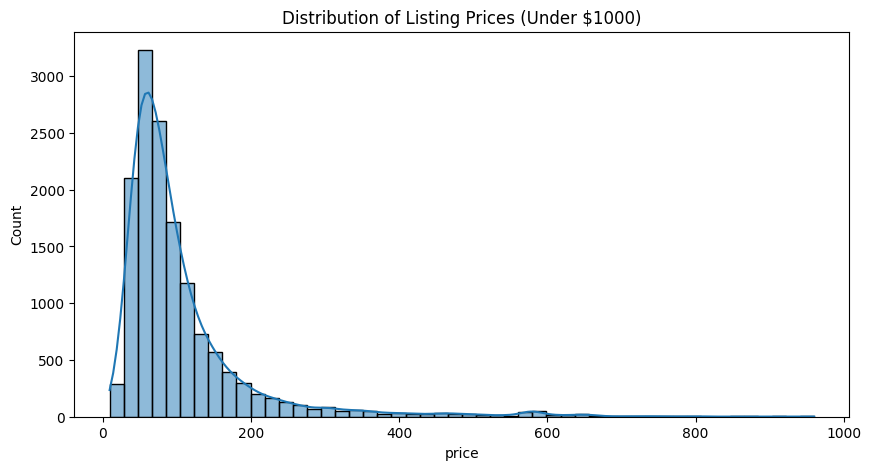

In [4]:
# 1. Identify and clean the 'price' column
# Remove '$' and ',' then convert to float
if df['price'].dtype == 'object':
    df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

print(f"Converted 'price' to {df['price'].dtype}")

# 2. Check your work with a summary
print("Price Summary Statistics:")
print(df['price'].describe())

# 3. Simple histogram to visualize distribution
plt.figure(figsize=(10, 5))
sns.histplot(df[df['price'] < 1000]['price'], bins=50, kde=True)
plt.title('Distribution of Listing Prices (Under $1000)')
plt.show()

### Reflection: :
1. What column did you fix?
   - I fixed the `price` column.
2. What cleaning steps did you apply?
   - I stripped the currency symbols ($) and commas, then cast the column from a string (object) to a float.
3. How does this help prepare the data for later use?
   - We are able to see average, see patterns and make predictions based on the model.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [5]:
# 1. Check for exact row duplicates
duplicate_rows = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_rows}")

# 2. Check for duplicate IDs (each listing should be unique)
duplicate_ids = df['id'].duplicated().sum()
print(f"Number of duplicate IDs: {duplicate_ids}")

# 3. Remove duplicates if they exist
if duplicate_ids > 0:
    df = df.drop_duplicates(subset='id', keep='first')
    print("Duplicate IDs removed.")
else:
    print("No duplicate IDs found.")

# Final check of data shape
print(f"Final dataset shape: {df.shape}")

Number of exact duplicate rows: 0
Number of duplicate IDs: 0
No duplicate IDs found.
Final dataset shape: (15584, 75)


### Reflection:
1. Did you find duplicates?

2. How did you decide what to drop or keep?
   
3. Why are duplicates risky for Airbnb teams?
  

### ✍️ Your Response:
1. I checked the ID column and found 0 duplicates.
2. I prioritized the 'id' column since it is the unique identifier for listings.
3. They skew metrics like inventory count and average nightly rates.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [6]:
# Export the cleaned dataframe to a CSV file
df.to_csv('cleaned_airbnb_data_6.csv', index=False)

print("File 'cleaned_airbnb_data_6.csv' has been exported successfully.")

File 'cleaned_airbnb_data_6.csv' has been exported successfully.


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response: 🔧

1. I think the hardest part was understanding what I wanted to clean and how to do that in python.  
2. Yes, I decided to remove license, and the neighborhod_group collums as they had very little useful data.
3. They will be able to use this to more accuratly predict patterns or future prices.
4. I would like to compare this data to other cities in Greece and see how the price changes the further away from the city you get.   
5. This assigment is allowing me to explore different ways to view data I gather which will be helpful in the future.


## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [7]:
!jupyter nbconvert --to html "assignment_06_data_cleaning.ipynb"

[NbConvertApp] WARNING | pattern 'assignment_06_data_cleaning.ipynb' matched no files
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent to: [--JupyterApp.answer_yes=Tru